In [13]:
# --- Visualization Setup ---

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12,6)

In [66]:
# Load stored DataFrames from data_loading notebook
%store -r df1
%store -r df2
%store -r df3
%store -r df4
%store -r df5
%store -r df6
%store -r df7
%store -r df8
%store -r df9
%store -r df10
%store -r orders


print("All DataFrames loaded successfully")

All DataFrames loaded successfully


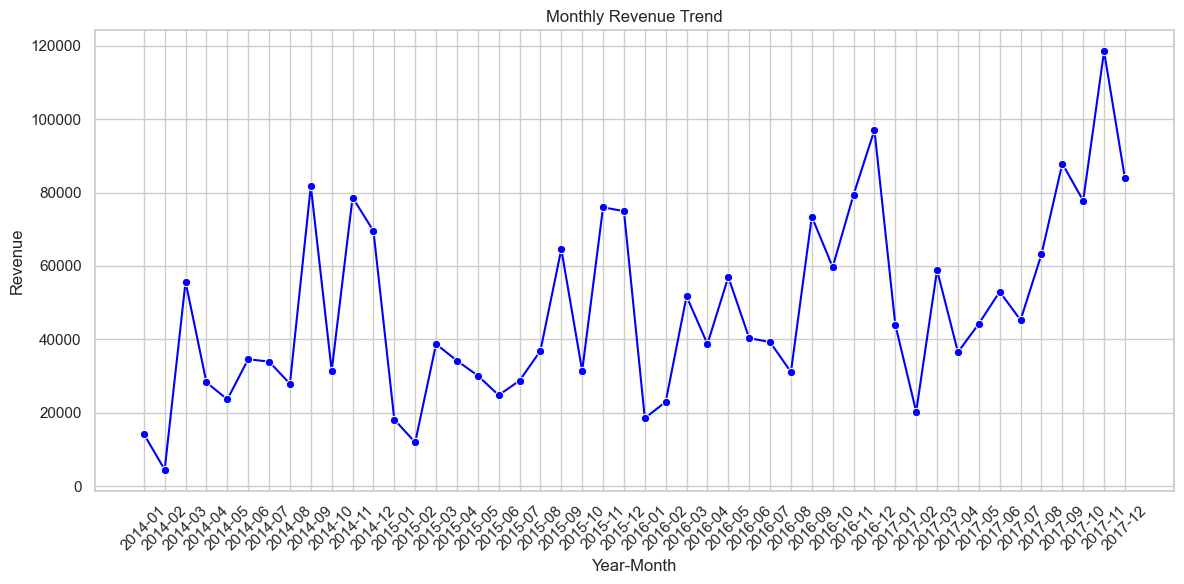

In [ ]:
# =============================
# #1 Monthly Revenue Trend - lineplot
# =============================


plt.figure(figsize=(12,6))
sns.lineplot(data=df1, x='year_month', y='revenue', marker='o', color='blue')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

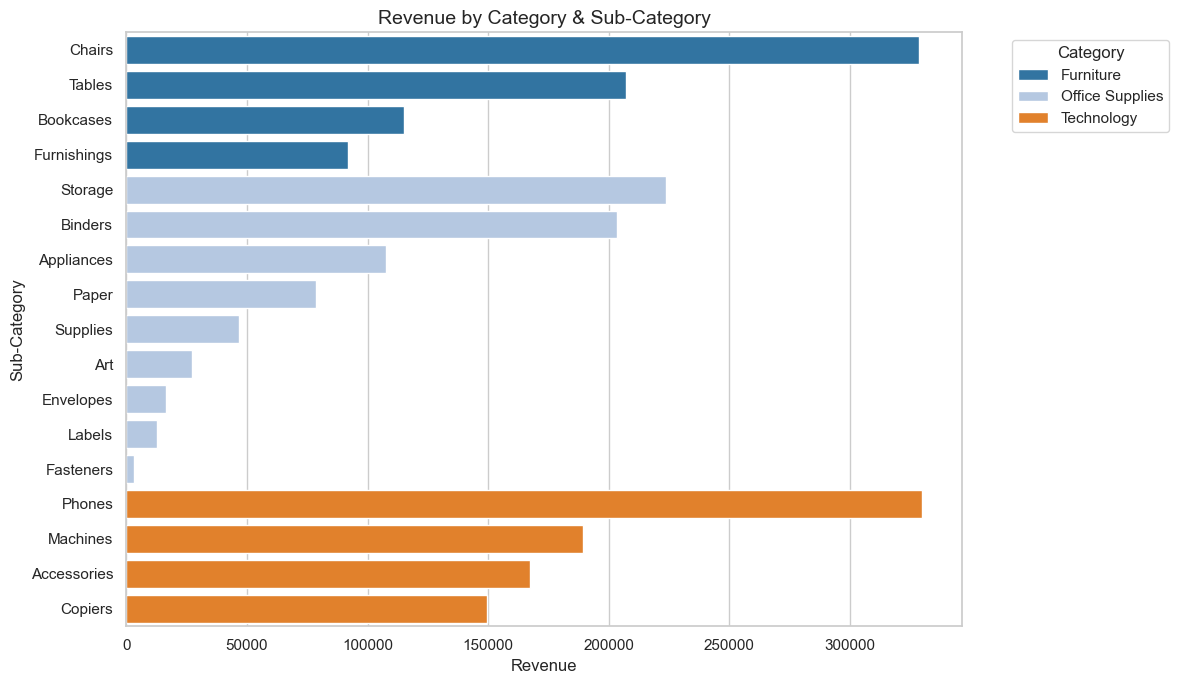

In [ ]:
# =============================
# #2 Category & Sub-Category Revenue (Ordered by Category Total and Sub-Category Revenue) - Barplot
# =============================


# Compute total revenue per category to order categories
category_totals = df7.groupby('category')['sub_category_revenue'].sum().sort_values(ascending=False).reset_index()
category_order = category_totals['category'].tolist()

# Sort sub-categories within each category by revenue (descending)
df7_sorted = df7.copy()
df7_sorted = df7_sorted[df7_sorted['category'].isin(category_order)]
df7_sorted = df7_sorted.sort_values(['category', 'sub_category_revenue'], ascending=[True, False])

plt.figure(figsize=(12,7))

sns.barplot(
    data=df7_sorted,
    x='sub_category_revenue',
    y='sub_category',
    hue='category',
    dodge=False,                # stacked-like appearance
    palette='tab20',
    order=df7_sorted['sub_category']
)

plt.title('Revenue by Category & Sub-Category', fontsize=14)
plt.xlabel('Revenue')
plt.ylabel('Sub-Category')
plt.ticklabel_format(style='plain', axis='x')  # remove scientific notation
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

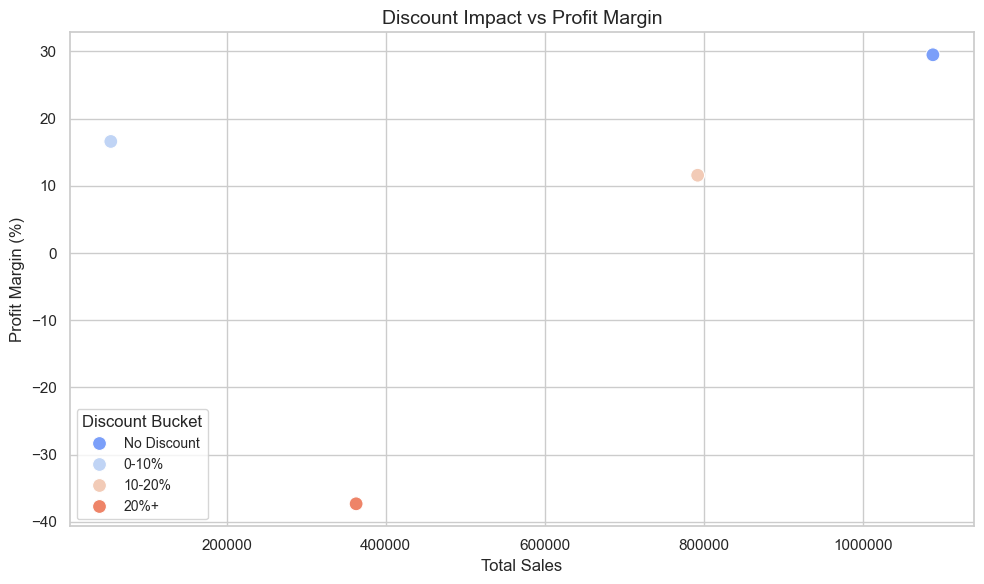

In [ ]:
# =============================
# #3 Visualization: Discount vs Profit Margin - scatterplot
# =============================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df8,  
    x='total_sales',
    y='profit_margin_pct',
    hue='discount_bucket',
    palette='coolwarm',
    s=100  # size of dots
)

plt.title('Discount Impact vs Profit Margin', fontsize=14)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Profit Margin (%)', fontsize=12)
plt.legend(title='Discount Bucket', fontsize=10)
plt.ticklabel_format(style='plain', axis='x')  # full sales numbers
plt.tight_layout()
plt.show()

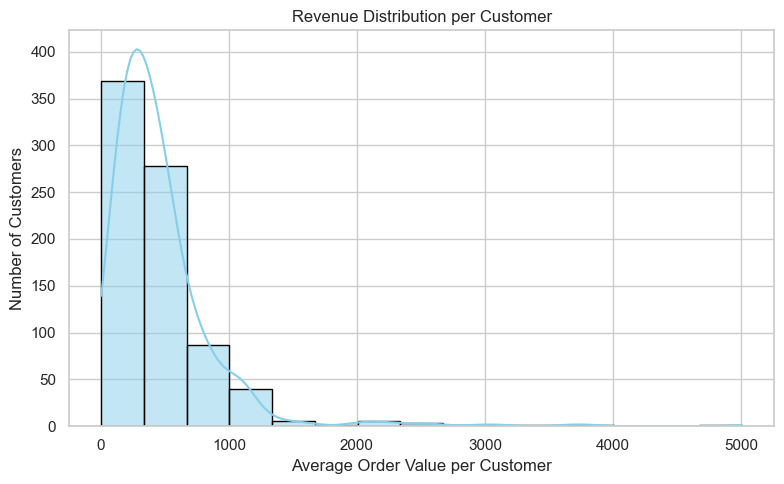

In [ ]:
# =============================
# #4 Revenue Distribution per Customer - histplot
# =============================

plt.figure(figsize=(8,5))

sns.histplot(
    data=df3,
    x='avg_order_value_per_customer',
    bins=15,          # adjusting number of bins for clarity
    kde=True,         # add smooth density curve
    color='skyblue',
    edgecolor='black'
)

plt.title('Revenue Distribution per Customer')
plt.xlabel('Average Order Value per Customer')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

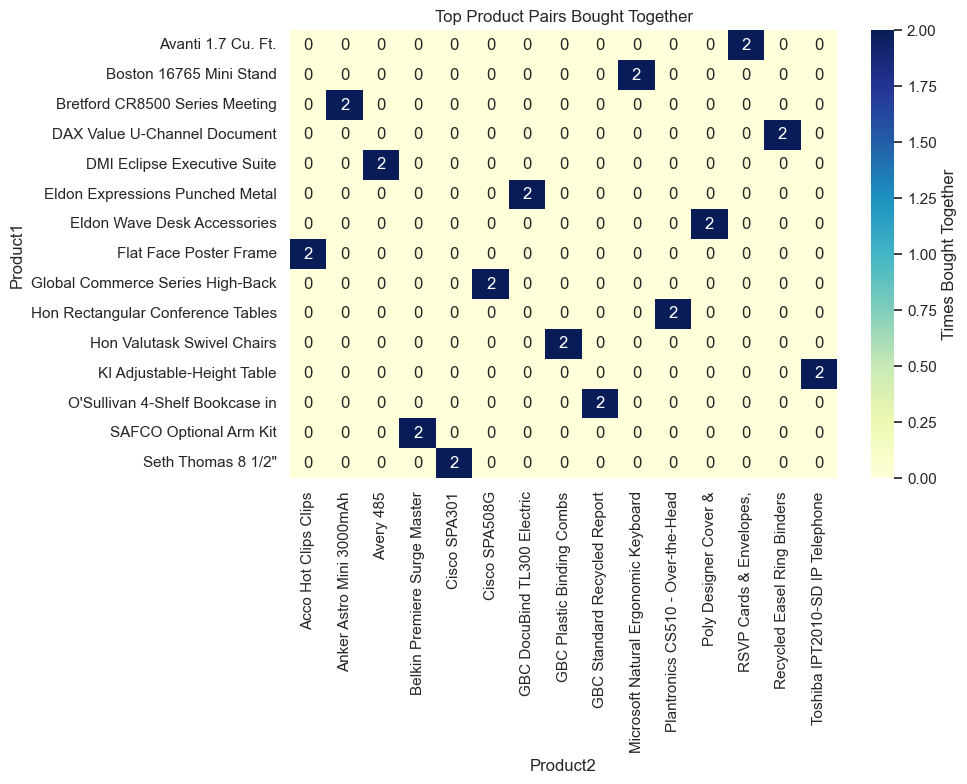

In [58]:
# =============================
# #5 Top Product Pairs Bought Together - Heatmap 
# =============================

# Take top 15 pairs by frequency
top_pairs = df10.sort_values('times_bought_together', ascending=False).head(15)

# Truncate actual product names to first 4 words for display
top_pairs['Product1'] = top_pairs['Product1_Name'].apply(lambda x: ' '.join(str(x).split()[:4]))
top_pairs['Product2'] = top_pairs['Product2_Name'].apply(lambda x: ' '.join(str(x).split()[:4]))

# Pivot for heatmap (rows = Product1, columns = Product2)
heatmap_data = top_pairs.pivot(index='Product1', columns='Product2', values='times_bought_together').fillna(0)

plt.figure(figsize=(10,8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap='YlGnBu',
    cbar_kws={'label': 'Times Bought Together'}
)
plt.title('Top Product Pairs Bought Together')
plt.tight_layout()
plt.show()

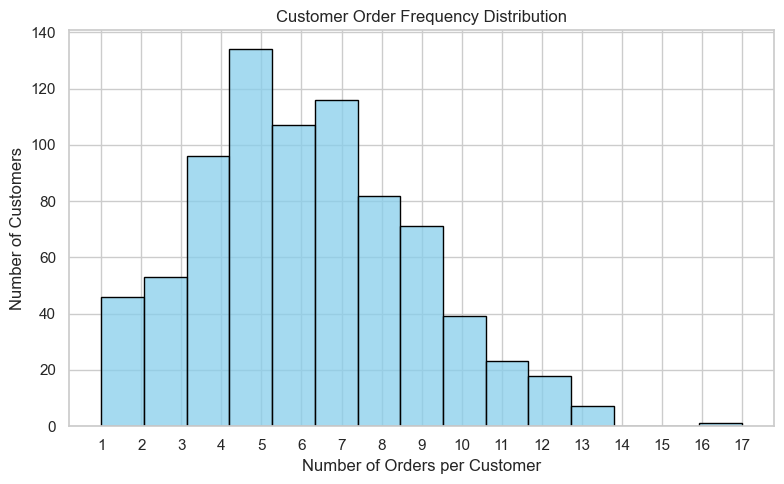

In [ ]:
# =============================
# #6 Customer Order Frequency
# =============================

customer_orders = orders.groupby('Customer ID')['Order ID'].nunique().reset_index()
customer_orders.rename(columns={'Order ID':'Order_Count'}, inplace=True)

plt.figure(figsize=(8,5))
sns.histplot(
    data=customer_orders,
    x='Order_Count',
    bins=15,
    kde=False,
    color='skyblue',
    edgecolor='black'
)
plt.title('Customer Order Frequency Distribution')
plt.xlabel('Number of Orders per Customer')
plt.ylabel('Number of Customers')
plt.xticks(range(1, customer_orders['Order_Count'].max()+1))
plt.tight_layout()
plt.show()